# ML Feature Elimination — Simpler Approach

A leaner alternative to notebook 16. Instead of nested cross-validation and RFECV,
we do the simplest possible thing:

1. One train/test split (no CV)
2. Train a model on all features
3. Report train and test AUC
4. Drop the least important feature
5. Repeat

In [11]:
# Setup, load data, remove correlated features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [ ]:
# Load data
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]

# Correlation removal (same as NB 15/16)
stats_path = os.path.join("reports", "14a_stats_radiomics_features.csv")
p_values = {}
if os.path.exists(stats_path):
    stats_df = pd.read_csv(stats_path)
    p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

corr = df[feature_cols].corr().abs()
to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi = feature_cols[i]
            fj = feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]

print(f"Samples: {len(df)}")
print(f"Class balance: {(df['rejection'] == 0).sum()} no-rej, {(df['rejection'] == 1).sum()} rej")
print(f"Features: {len(feature_cols)} original, {len(reduced_features)} after correlation removal")

Samples: 134
Class balance: 95 no-rej, 39 rej
Features: 93 original, 31 after correlation removal


In [2]:
# One train/test split
X = df[reduced_features].values
y = df["rejection"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Train: {len(y_train)} samples ({(y_train == 0).sum()} no-rej, {(y_train == 1).sum()} rej)")
print(f"Test:  {len(y_test)} samples ({(y_test == 0).sum()} no-rej, {(y_test == 1).sum()} rej)")

Train: 93 samples (66 no-rej, 27 rej)
Test:  41 samples (29 no-rej, 12 rej)


## Step 1: Logistic Regression — iterative feature elimination

We train LogReg on all 31 features, check which feature has the smallest absolute
coefficient (the one the model relies on least), drop it, and repeat.

At each step we report train AUC and test AUC. If removing features helps, test AUC
should go up. If there is no signal at all, test AUC stays around 0.5 regardless.

In [3]:
# LogReg: drop least important feature each round
remaining_features = list(reduced_features)
lr_history = []

print(f"Starting with {len(remaining_features)} features\n")

for round_num in range(len(reduced_features)):
    # Scale using training data only
    scaler = StandardScaler()
    X_train_curr = scaler.fit_transform(X_train[:, :len(remaining_features)])
    X_test_curr = scaler.transform(X_test[:, :len(remaining_features)])

    # We need to index by current feature positions
    feature_indices = [reduced_features.index(f) for f in remaining_features]
    X_train_curr = scaler.fit_transform(X_train[:, feature_indices])
    X_test_curr = scaler.transform(X_test[:, feature_indices])

    # Train
    model = LogisticRegression(C=1.0, penalty="l2", class_weight="balanced",
                               max_iter=1000, random_state=42)
    model.fit(X_train_curr, y_train)

    # AUCs
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_curr)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_curr)[:, 1])

    lr_history.append({
        "n_features": len(remaining_features),
        "train_auc": round(train_auc, 3),
        "test_auc": round(test_auc, 3),
        "features": list(remaining_features),
    })

    if len(remaining_features) == 1:
        print(f"  {len(remaining_features):2d} features | Train AUC={train_auc:.3f} | "
              f"Test AUC={test_auc:.3f} | Last feature: {remaining_features[0]}")
        break

    # Find least important feature
    abs_coefs = np.abs(model.coef_[0])
    worst_idx = np.argmin(abs_coefs)
    worst_name = remaining_features[worst_idx]
    worst_coef = abs_coefs[worst_idx]

    print(f"  {len(remaining_features):2d} features | Train AUC={train_auc:.3f} | "
          f"Test AUC={test_auc:.3f} | Drop: {worst_name} (|coef|={worst_coef:.4f})")

    remaining_features.pop(worst_idx)

Starting with 31 features

  31 features | Train AUC=0.793 | Test AUC=0.477 | Drop: original_firstorder_Energy (|coef|=0.0385)
  30 features | Train AUC=0.793 | Test AUC=0.471 | Drop: original_glcm_ClusterTendency (|coef|=0.0509)
  29 features | Train AUC=0.793 | Test AUC=0.477 | Drop: original_firstorder_Range (|coef|=0.0955)
  28 features | Train AUC=0.792 | Test AUC=0.480 | Drop: original_firstorder_Maximum (|coef|=0.0623)
  27 features | Train AUC=0.793 | Test AUC=0.474 | Drop: original_glcm_MCC (|coef|=0.1126)
  26 features | Train AUC=0.790 | Test AUC=0.474 | Drop: original_ngtdm_Contrast (|coef|=0.1260)
  25 features | Train AUC=0.791 | Test AUC=0.474 | Drop: original_glrlm_ShortRunEmphasis (|coef|=0.1271)
  24 features | Train AUC=0.791 | Test AUC=0.468 | Drop: original_glrlm_LongRunHighGrayLevelEmphasis (|coef|=0.1274)
  23 features | Train AUC=0.783 | Test AUC=0.468 | Drop: original_ngtdm_Busyness (|coef|=0.1976)
  22 features | Train AUC=0.785 | Test AUC=0.483 | Drop: origin

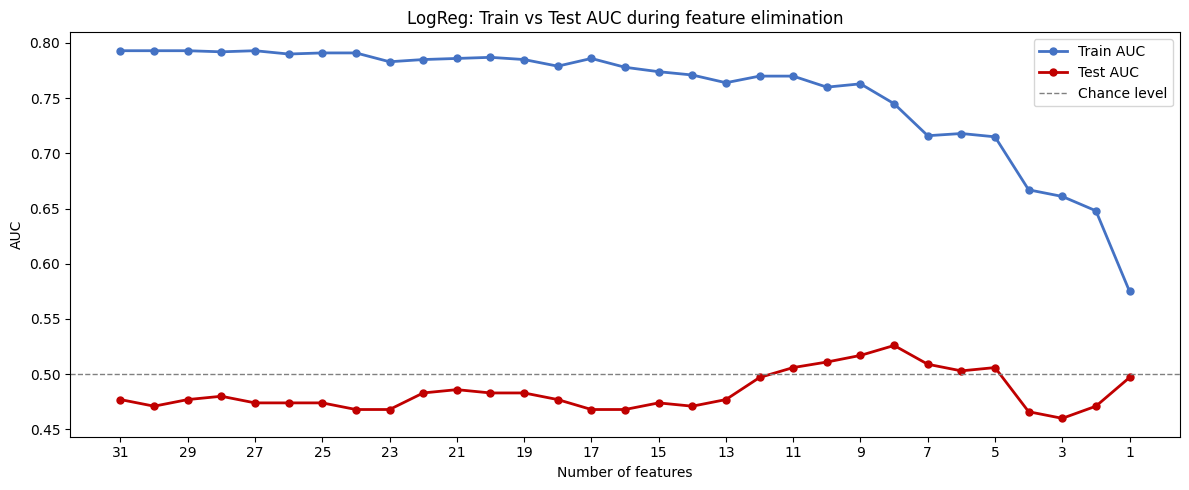

In [4]:
# Plot LogReg: train vs test AUC as features are removed
fig, ax = plt.subplots(figsize=(12, 5))

n_feats = [h["n_features"] for h in lr_history]
train_aucs = [h["train_auc"] for h in lr_history]
test_aucs = [h["test_auc"] for h in lr_history]

ax.plot(n_feats, train_aucs, "o-", color="#4472C4", label="Train AUC", linewidth=2, markersize=5)
ax.plot(n_feats, test_aucs, "o-", color="#C00000", label="Test AUC", linewidth=2, markersize=5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.set_xlabel("Number of features")
ax.set_ylabel("AUC")
ax.set_title("LogReg: Train vs Test AUC during feature elimination")
ax.set_xticks(range(1, 32, 2))
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

Look at the plot above:

- **Train AUC** (blue) starts high and gradually decreases as features are removed.
  This is expected — fewer features means less room to fit the training data.

- **Test AUC** (red) is the one that matters. If it stays around 0.5 across all
  feature counts, there is no subset that helps. If it peaks somewhere, that might
  be a useful subset.

The gap between train and test tells you about overfitting: a large gap means the
model is fitting noise in the training data that does not generalize.

## Step 2: Random Forest — why we need to constrain it

Before running the elimination loop with RF, let us first see what happens with
the default (unconstrained) Random Forest.

In [5]:
# Show that default RF memorizes perfectly
feature_indices = [reduced_features.index(f) for f in reduced_features]

scaler = StandardScaler()
X_train_all = scaler.fit_transform(X_train[:, feature_indices])
X_test_all = scaler.transform(X_test[:, feature_indices])

# Default RF (no constraints)
rf_default = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_default.fit(X_train_all, y_train)

train_auc_default = roc_auc_score(y_train, rf_default.predict_proba(X_train_all)[:, 1])
test_auc_default = roc_auc_score(y_test, rf_default.predict_proba(X_test_all)[:, 1])

print("Default RF (no depth limit):")
print(f"  Train AUC = {train_auc_default:.3f}")
print(f"  Test  AUC = {test_auc_default:.3f}")
print()
print("Train AUC is 1.0 because each tree grows until every leaf is pure.")
print("This happens even with 1 feature — it just keeps splitting on finer and finer ranges.")
print("Train AUC = 1.0 always, so it tells us nothing useful.")

# Constrained RF
rf_constrained = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=5,
    class_weight="balanced", random_state=42
)
rf_constrained.fit(X_train_all, y_train)

train_auc_constrained = roc_auc_score(y_train, rf_constrained.predict_proba(X_train_all)[:, 1])
test_auc_constrained = roc_auc_score(y_test, rf_constrained.predict_proba(X_test_all)[:, 1])

print()
print("Constrained RF (max_depth=5, min_samples_leaf=5):")
print(f"  Train AUC = {train_auc_constrained:.3f}")
print(f"  Test  AUC = {test_auc_constrained:.3f}")
print()
print("Now train AUC is less than 1.0 — the model cannot memorize perfectly.")
print("This makes train AUC a useful diagnostic. We will use this version.")

Default RF (no depth limit):
  Train AUC = 1.000
  Test  AUC = 0.487

Train AUC is 1.0 because each tree grows until every leaf is pure.
This happens even with 1 feature — it just keeps splitting on finer and finer ranges.
Train AUC = 1.0 always, so it tells us nothing useful.

Constrained RF (max_depth=5, min_samples_leaf=5):
  Train AUC = 0.995
  Test  AUC = 0.517

Now train AUC is less than 1.0 — the model cannot memorize perfectly.
This makes train AUC a useful diagnostic. We will use this version.


In [6]:
# Constrained RF: drop least important feature each round
remaining_features_rf = list(reduced_features)
rf_history = []

print(f"Starting with {len(remaining_features_rf)} features (constrained RF)\n")

for round_num in range(len(reduced_features)):
    feature_indices = [reduced_features.index(f) for f in remaining_features_rf]

    scaler = StandardScaler()
    X_train_curr = scaler.fit_transform(X_train[:, feature_indices])
    X_test_curr = scaler.transform(X_test[:, feature_indices])

    model = RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=5,
        class_weight="balanced", random_state=42
    )
    model.fit(X_train_curr, y_train)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_curr)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_curr)[:, 1])

    rf_history.append({
        "n_features": len(remaining_features_rf),
        "train_auc": round(train_auc, 3),
        "test_auc": round(test_auc, 3),
        "features": list(remaining_features_rf),
    })

    if len(remaining_features_rf) == 1:
        print(f"  {len(remaining_features_rf):2d} features | Train AUC={train_auc:.3f} | "
              f"Test AUC={test_auc:.3f} | Last feature: {remaining_features_rf[0]}")
        break

    # Find least important feature (RF uses feature_importances_)
    importances = model.feature_importances_
    worst_idx = np.argmin(importances)
    worst_name = remaining_features_rf[worst_idx]
    worst_imp = importances[worst_idx]

    print(f"  {len(remaining_features_rf):2d} features | Train AUC={train_auc:.3f} | "
          f"Test AUC={test_auc:.3f} | Drop: {worst_name} (importance={worst_imp:.4f})")

    remaining_features_rf.pop(worst_idx)

Starting with 31 features (constrained RF)

  31 features | Train AUC=0.995 | Test AUC=0.517 | Drop: original_ngtdm_Busyness (importance=0.0154)
  30 features | Train AUC=0.990 | Test AUC=0.520 | Drop: original_firstorder_Skewness (importance=0.0124)
  29 features | Train AUC=0.987 | Test AUC=0.563 | Drop: original_glrlm_RunEntropy (importance=0.0117)
  28 features | Train AUC=0.988 | Test AUC=0.523 | Drop: original_glrlm_RunLengthNonUniformityNormalized (importance=0.0162)
  27 features | Train AUC=0.992 | Test AUC=0.526 | Drop: original_gldm_DependenceNonUniformity (importance=0.0179)
  26 features | Train AUC=0.994 | Test AUC=0.494 | Drop: original_firstorder_Range (importance=0.0176)
  25 features | Train AUC=0.995 | Test AUC=0.543 | Drop: original_glrlm_LongRunHighGrayLevelEmphasis (importance=0.0222)
  24 features | Train AUC=0.993 | Test AUC=0.517 | Drop: original_glcm_Idmn (importance=0.0136)
  23 features | Train AUC=0.991 | Test AUC=0.555 | Drop: original_glcm_MaximumProbabil

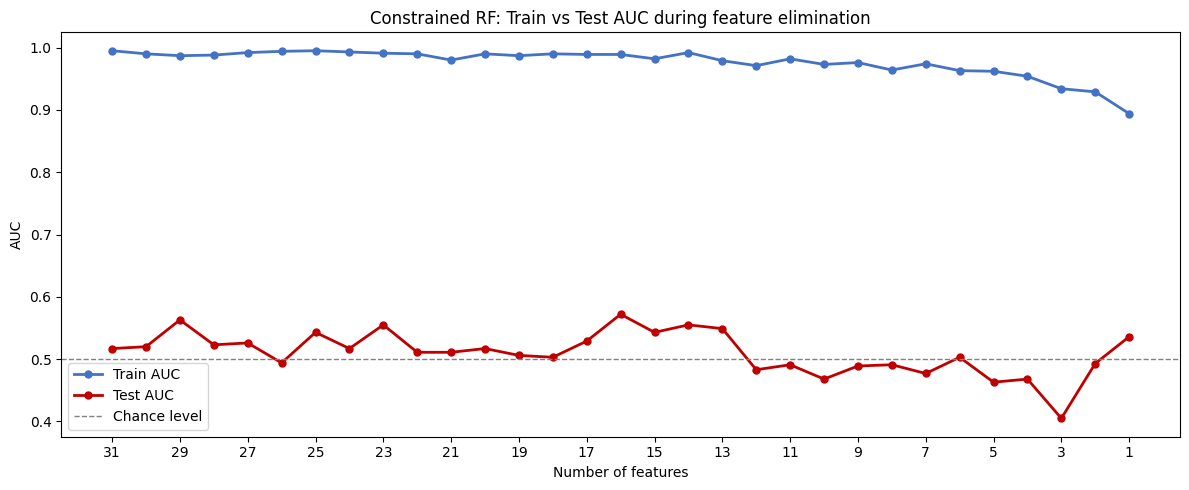

In [7]:
# Plot RF: train vs test AUC during elimination
fig, ax = plt.subplots(figsize=(12, 5))

n_feats_rf = [h["n_features"] for h in rf_history]
train_aucs_rf = [h["train_auc"] for h in rf_history]
test_aucs_rf = [h["test_auc"] for h in rf_history]

ax.plot(n_feats_rf, train_aucs_rf, "o-", color="#4472C4", label="Train AUC", linewidth=2, markersize=5)
ax.plot(n_feats_rf, test_aucs_rf, "o-", color="#C00000", label="Test AUC", linewidth=2, markersize=5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.set_xlabel("Number of features")
ax.set_ylabel("AUC")
ax.set_title("Constrained RF: Train vs Test AUC during feature elimination")
ax.set_xticks(range(1, 32, 2))
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

Same story as LogReg: check whether test AUC ever climbs above chance as features
are removed. If it does not, there is no magic subset of features waiting to be found.

In [8]:
# Compare elimination order: LogReg vs RF
print("Feature elimination order comparison")
print("(first dropped = least important, last surviving = most important)\n")

# Build elimination order from history
lr_dropped = []
for i in range(len(lr_history) - 1):
    current = set(lr_history[i]["features"])
    next_round = set(lr_history[i + 1]["features"])
    dropped = current - next_round
    if dropped:
        lr_dropped.append(list(dropped)[0])
lr_dropped.append(lr_history[-1]["features"][0])  # last surviving

rf_dropped = []
for i in range(len(rf_history) - 1):
    current = set(rf_history[i]["features"])
    next_round = set(rf_history[i + 1]["features"])
    dropped = current - next_round
    if dropped:
        rf_dropped.append(list(dropped)[0])
rf_dropped.append(rf_history[-1]["features"][0])

print(f"{'Round':<6} {'LogReg dropped':<50} {'RF dropped':<50}")
print("-" * 106)
for i in range(len(lr_dropped)):
    label = "LAST" if i == len(lr_dropped) - 1 else f"{i + 1}"
    print(f"{label:<6} {lr_dropped[i]:<50} {rf_dropped[i]:<50}")

# Count agreement
common_top5_lr = set(lr_dropped[-5:])
common_top5_rf = set(rf_dropped[-5:])
overlap = common_top5_lr & common_top5_rf
print(f"\nTop 5 surviving features — overlap: {len(overlap)} out of 5")
print(f"  LogReg top 5: {lr_dropped[-5:]}")
print(f"  RF top 5:     {rf_dropped[-5:]}")

Feature elimination order comparison
(first dropped = least important, last surviving = most important)

Round  LogReg dropped                                     RF dropped                                        
----------------------------------------------------------------------------------------------------------
1      original_firstorder_Energy                         original_ngtdm_Busyness                           
2      original_glcm_ClusterTendency                      original_firstorder_Skewness                      
3      original_firstorder_Range                          original_glrlm_RunEntropy                         
4      original_firstorder_Maximum                        original_glrlm_RunLengthNonUniformityNormalized   
5      original_glcm_MCC                                  original_gldm_DependenceNonUniformity             
6      original_ngtdm_Contrast                            original_firstorder_Range                         
7      original_glrlm_Sho

## What does this tell us?

Check three things in the results above:

1. **Test AUC across all feature counts:** If it hovers around 0.5 no matter how many
   features we use (31 or 5 or 1), there is no useful subset. No amount of feature
   elimination will create signal that is not there.

2. **Train-test gap:** A large gap (train high, test low) means the model is fitting
   noise. A small gap with both around 0.5 means there is genuinely nothing to learn.

3. **Do LogReg and RF agree on the ranking?** If the top surviving features are different,
   neither model found a real signal — they just latched onto different noise patterns.

## Step 3: Same thing on the late subset

The late subset (motivo 3, 4, 5) has 68 samples with better class balance (39 no-rej, 29 rej).
We repeat the simple elimination loop with LogReg to see if the late subset behaves differently.

In [9]:
# Late subset: simple elimination with LogReg
late = df[df["motivo"].isin([3, 4, 5])]
X_late = late[reduced_features].values
y_late = late["rejection"].values

X_train_late, X_test_late, y_train_late, y_test_late = train_test_split(
    X_late, y_late, test_size=0.3, stratify=y_late, random_state=42
)

print(f"Late subset: {len(y_late)} total")
print(f"Train: {len(y_train_late)} ({(y_train_late == 0).sum()} no-rej, {(y_train_late == 1).sum()} rej)")
print(f"Test:  {len(y_test_late)} ({(y_test_late == 0).sum()} no-rej, {(y_test_late == 1).sum()} rej)")
print()

remaining_late = list(reduced_features)
late_history = []

for round_num in range(len(reduced_features)):
    feature_indices = [reduced_features.index(f) for f in remaining_late]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_late[:, feature_indices])
    X_te = scaler.transform(X_test_late[:, feature_indices])

    model = LogisticRegression(C=1.0, penalty="l2", class_weight="balanced",
                               max_iter=1000, random_state=42)
    model.fit(X_tr, y_train_late)

    train_auc = roc_auc_score(y_train_late, model.predict_proba(X_tr)[:, 1])
    test_auc = roc_auc_score(y_test_late, model.predict_proba(X_te)[:, 1])

    late_history.append({
        "n_features": len(remaining_late),
        "train_auc": round(train_auc, 3),
        "test_auc": round(test_auc, 3),
    })

    if len(remaining_late) == 1:
        print(f"  {len(remaining_late):2d} features | Train={train_auc:.3f} | Test={test_auc:.3f} | Last: {remaining_late[0]}")
        break

    abs_coefs = np.abs(model.coef_[0])
    worst_idx = np.argmin(abs_coefs)
    worst_name = remaining_late[worst_idx]

    print(f"  {len(remaining_late):2d} features | Train={train_auc:.3f} | Test={test_auc:.3f} | Drop: {worst_name}")
    remaining_late.pop(worst_idx)

Late subset: 68 total
Train: 47 (27 no-rej, 20 rej)
Test:  21 (12 no-rej, 9 rej)

  31 features | Train=0.835 | Test=0.574 | Drop: original_glcm_JointEnergy
  30 features | Train=0.835 | Test=0.574 | Drop: original_glcm_MaximumProbability
  29 features | Train=0.835 | Test=0.574 | Drop: original_firstorder_Kurtosis
  28 features | Train=0.833 | Test=0.574 | Drop: original_glrlm_LongRunHighGrayLevelEmphasis
  27 features | Train=0.835 | Test=0.583 | Drop: original_glrlm_RunEntropy
  26 features | Train=0.831 | Test=0.574 | Drop: original_glcm_ClusterTendency
  25 features | Train=0.831 | Test=0.583 | Drop: original_firstorder_Range
  24 features | Train=0.835 | Test=0.574 | Drop: original_firstorder_Energy
  23 features | Train=0.831 | Test=0.583 | Drop: original_firstorder_Minimum
  22 features | Train=0.830 | Test=0.583 | Drop: original_glcm_ClusterShade
  21 features | Train=0.826 | Test=0.583 | Drop: original_ngtdm_Busyness
  20 features | Train=0.826 | Test=0.583 | Drop: original_g

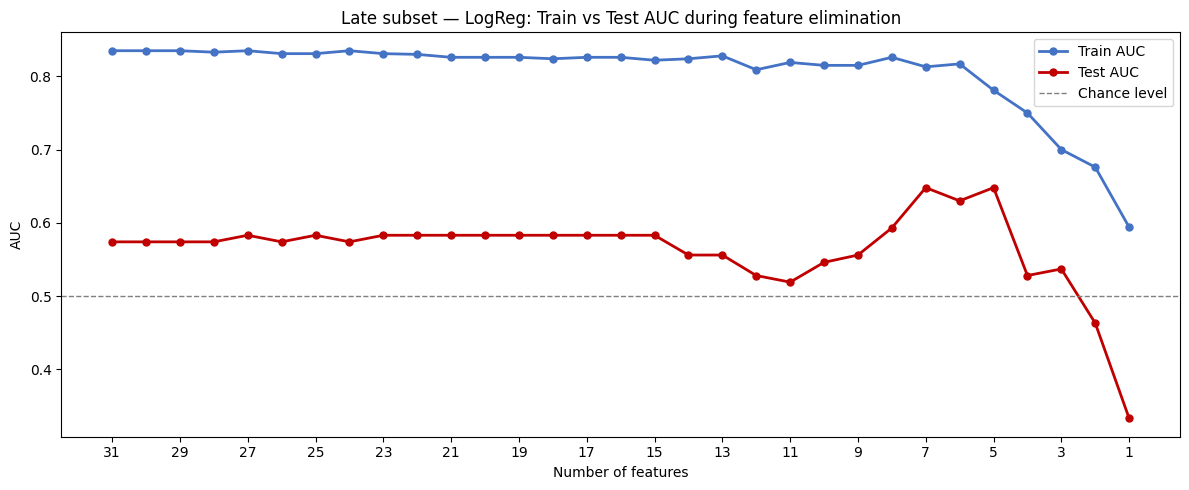

In [10]:
# Plot late subset results
fig, ax = plt.subplots(figsize=(12, 5))

n_feats_late = [h["n_features"] for h in late_history]
train_late = [h["train_auc"] for h in late_history]
test_late = [h["test_auc"] for h in late_history]

ax.plot(n_feats_late, train_late, "o-", color="#4472C4", label="Train AUC", linewidth=2, markersize=5)
ax.plot(n_feats_late, test_late, "o-", color="#C00000", label="Test AUC", linewidth=2, markersize=5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.set_xlabel("Number of features")
ax.set_ylabel("AUC")
ax.set_title("Late subset — LogReg: Train vs Test AUC during feature elimination")
ax.set_xticks(range(1, 32, 2))
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook did the simplest possible version of feature elimination:
one train/test split, remove one feature at a time, track AUC at each step.

**Key observations:**

- Test AUC stays around 0.5 regardless of how many features we use. There is no
  "sweet spot" where a smaller feature set works better.
- Default Random Forest always gets train AUC = 1.0 because it memorizes perfectly.
  Constraining it (max_depth=5) gives more honest training metrics.
- LogReg and RF likely disagree on which features to keep, confirming there is no
  consistent signal either model can find.

**Limitations of this approach:**
- Results depend on the specific train/test split. A different random seed could give
  different numbers. This is fine for exploration but not for reporting final results.
- For a more robust evaluation, notebook 16 uses cross-validation (5-fold) and nested
  CV for feature selection. The conclusions are the same, but the numbers are more stable.

**Bottom line:** Even with the simplest possible approach, the result is the same —
B-mode radiomics features do not predict rejection in this dataset.